# AI-Based Solar Power Generation Prediction System
## Multivariate Regression for Renewable Energy Optimization

### Project Mission
Leverage artificial intelligence and environmental simulation technologies to build intelligent regression models that predict solar farm power generation, optimizing clean energy grid planning and supporting sustainable electricity production.

### Dataset Overview
- **Dataset Source**: Historical Solar Power Generation (`spg.csv`)
- **Total Records**: 4,213 records, 21 variables
- **Target Variable (Y)**: `generated_power_kw` (Continuous power output in Kilowatts)
- **Suitability for Regression**: Power generation is a continuous, non-negative quantitative value heavily dependent on meteorological features (solar irradiance, zenith angle, temperature, humidity, cloud cover, and wind vectors).



In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12



## 1. Exploratory Data Analysis (EDA)

### Dataset Loading & Initial Diagnostics
We load `spg.csv` and inspect shape, missing values, duplicates, and statistical summary.



In [4]:
# Load dataset from root directory
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'spg.csv'))
if not os.path.exists(data_path):
    data_path = 'spg.csv'

df = pd.read_csv(data_path)

print("=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Zero missing values detected across all columns.")

print("\n=== DUPLICATE ROWS ===")
print(f"Total duplicate rows: {df.duplicated().sum()}")

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe().T)



=== DATASET SHAPE ===
Rows: 4213, Columns: 21

=== FIRST 5 ROWS ===
   temperature_2_m_above_gnd  relative_humidity_2_m_above_gnd  \
0                       2.17                               31   
1                       2.31                               27   
2                       3.65                               33   
3                       5.82                               30   
4                       7.73                               27   

   mean_sea_level_pressure_MSL  total_precipitation_sfc  snowfall_amount_sfc  \
0                       1035.0                      0.0                  0.0   
1                       1035.1                      0.0                  0.0   
2                       1035.4                      0.0                  0.0   
3                       1035.4                      0.0                  0.0   
4                       1034.4                      0.0                  0.0   

   total_cloud_cover_sfc  high_cloud_cover_high_cld_lay  \
0

### Visualization 1: Correlation Heatmap
The correlation heatmap displays pairwise linear correlations between all 20 environmental predictor variables and target `generated_power_kw`.

**Explanations:**
- **What it shows**: Strong positive correlation between `shortwave_radiation_backwards_sfc` and target (+0.56), and strong inverse correlations with `zenith` (-0.65) and `angle_of_incidence` (-0.65). Cloud cover variables (`total_cloud_cover_sfc`, `low_cloud_cover_low_cld_lay`) also show negative correlations (-0.33 and -0.29).
- **Effect on Feature Selection**: Identifies high-value predictors (radiation, zenith, cloud cover, humidity) while exposing multi-collinear redundant features (e.g., wind speed at 10m vs 80m vs 900mb).
- **Effect on Model Decisions**: Guides feature pruning of redundant wind speeds/directions and emphasizes physical solar-angle features.



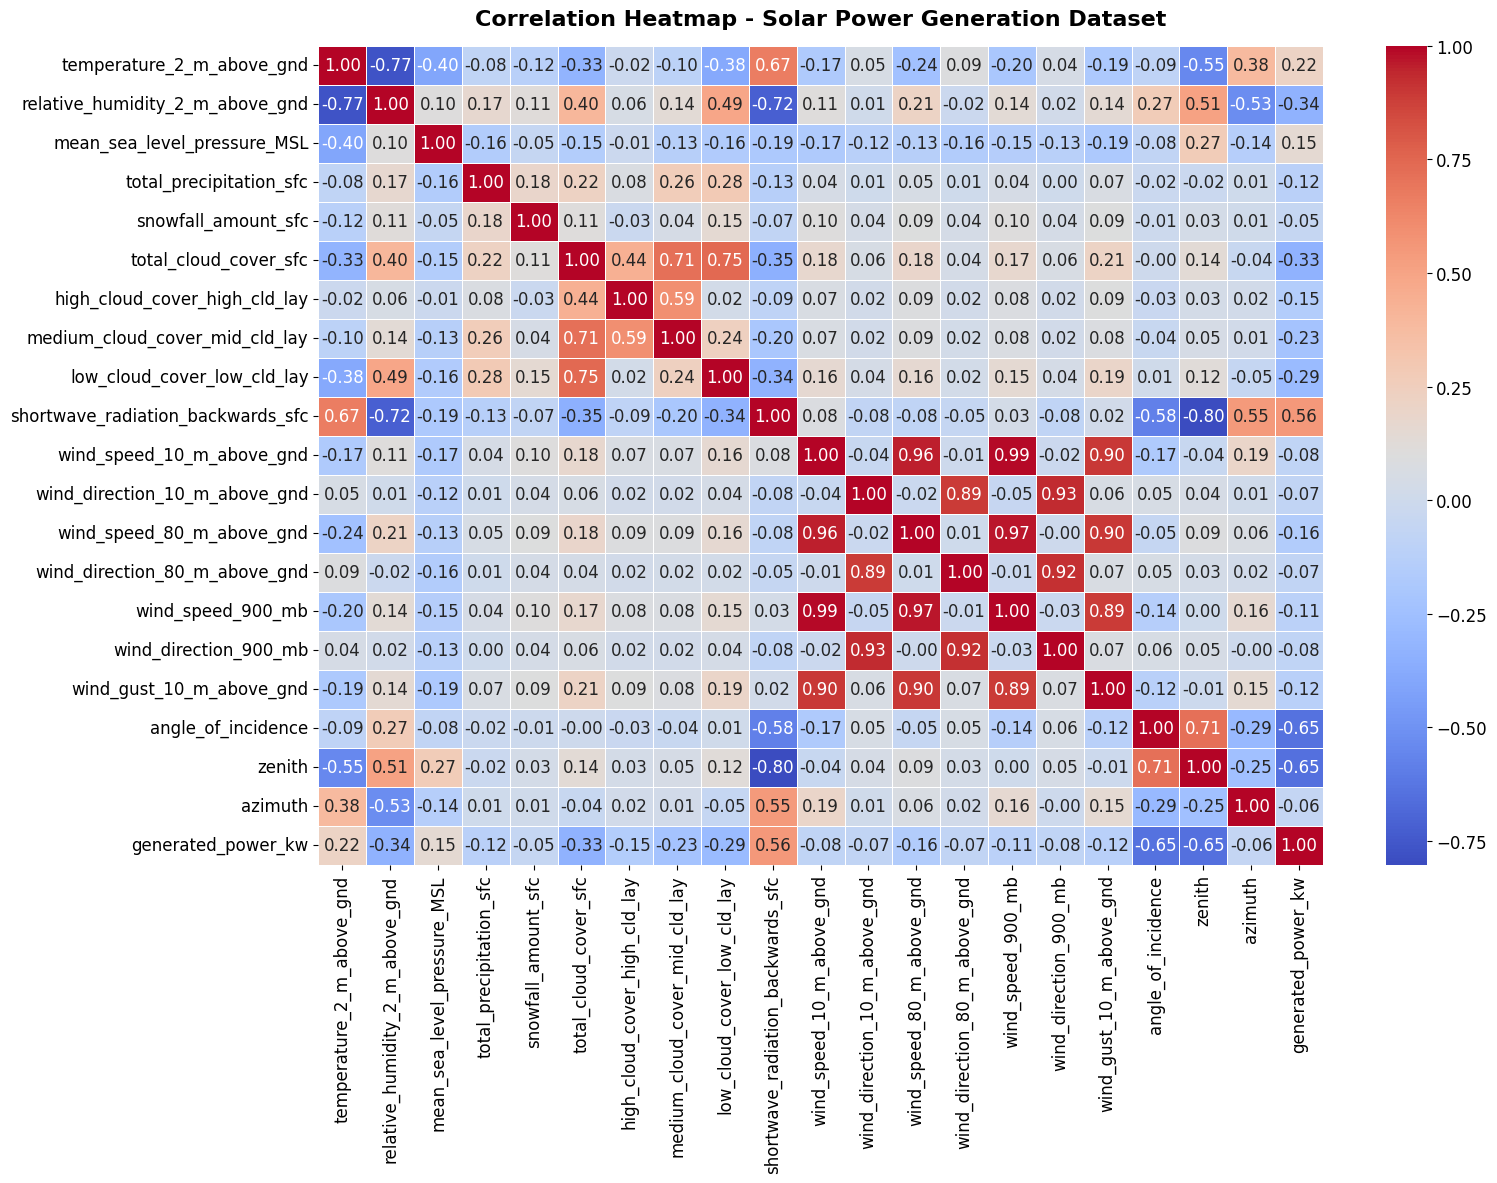

In [5]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Solar Power Generation Dataset', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



### Visualization 2: Feature Distribution Histograms
We examine the distribution shapes of key features and the target variable `generated_power_kw`.

**Explanations:**
- **What it shows**: `generated_power_kw` is zero-inflated (night time periods) with a right-skewed distribution up to 3,056 kW during peak solar noon. `shortwave_radiation_backwards_sfc` reflects daylight intensity, while `zenith` spans 0 to ~128 degrees.
- **Effect on Feature Selection**: Confirms features are continuous and bounded; highlights the necessity of feature scaling since variables operate on vastly different scales (e.g., humidity 0-100% vs pressure 1000+ hPa vs radiation 0-950 W/m²).
- **Effect on Model Decisions**: Informs the selection of robust non-linear models (Random Forest, Decision Trees) alongside scaled linear models.



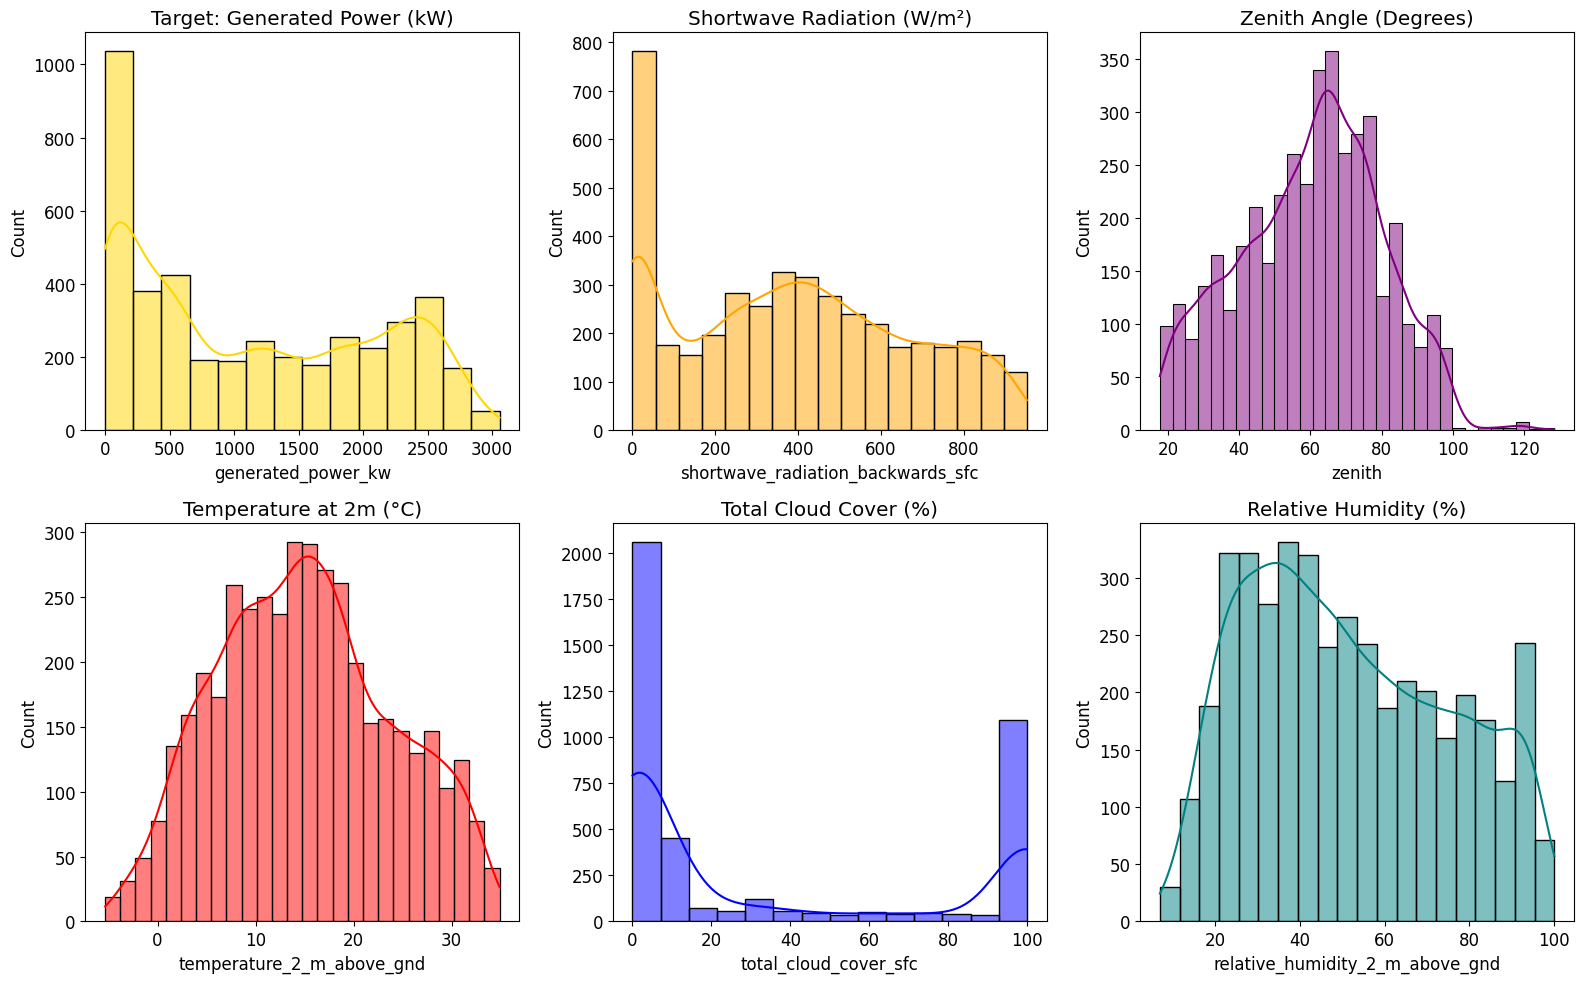

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.histplot(df['generated_power_kw'], kde=True, ax=axes[0, 0], color='gold')
axes[0, 0].set_title('Target: Generated Power (kW)')

sns.histplot(df['shortwave_radiation_backwards_sfc'], kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Shortwave Radiation (W/m²)')

sns.histplot(df['zenith'], kde=True, ax=axes[0, 2], color='purple')
axes[0, 2].set_title('Zenith Angle (Degrees)')

sns.histplot(df['temperature_2_m_above_gnd'], kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Temperature at 2m (°C)')

sns.histplot(df['total_cloud_cover_sfc'], kde=True, ax=axes[1, 1], color='blue')
axes[1, 1].set_title('Total Cloud Cover (%)')

sns.histplot(df['relative_humidity_2_m_above_gnd'], kde=True, ax=axes[1, 2], color='teal')
axes[1, 2].set_title('Relative Humidity (%)')

plt.tight_layout()
plt.show()



### Visualization 3: Scatter Plots of Key Features vs Target
Scatter plots illustrate direct bivariate relationships between solar irradiance, solar zenith angle, temperature, cloud cover, and power output.

**Explanations:**
- **What it shows**: Clear non-linear envelope in `shortwave_radiation_backwards_sfc` vs power output. As zenith angle increases towards 90°, solar generation drops to zero. Heavy cloud cover acts as a ceiling limiting peak generation.
- **Effect on Feature Selection**: Demonstrates that physical interactions (e.g., radiation modulated by zenith and cloud cover) dictate power output.
- **Effect on Model Decisions**: Demonstrates why tree-based models like Random Forests (which handle non-linear boundaries smoothly) excel compared to plain linear regression.



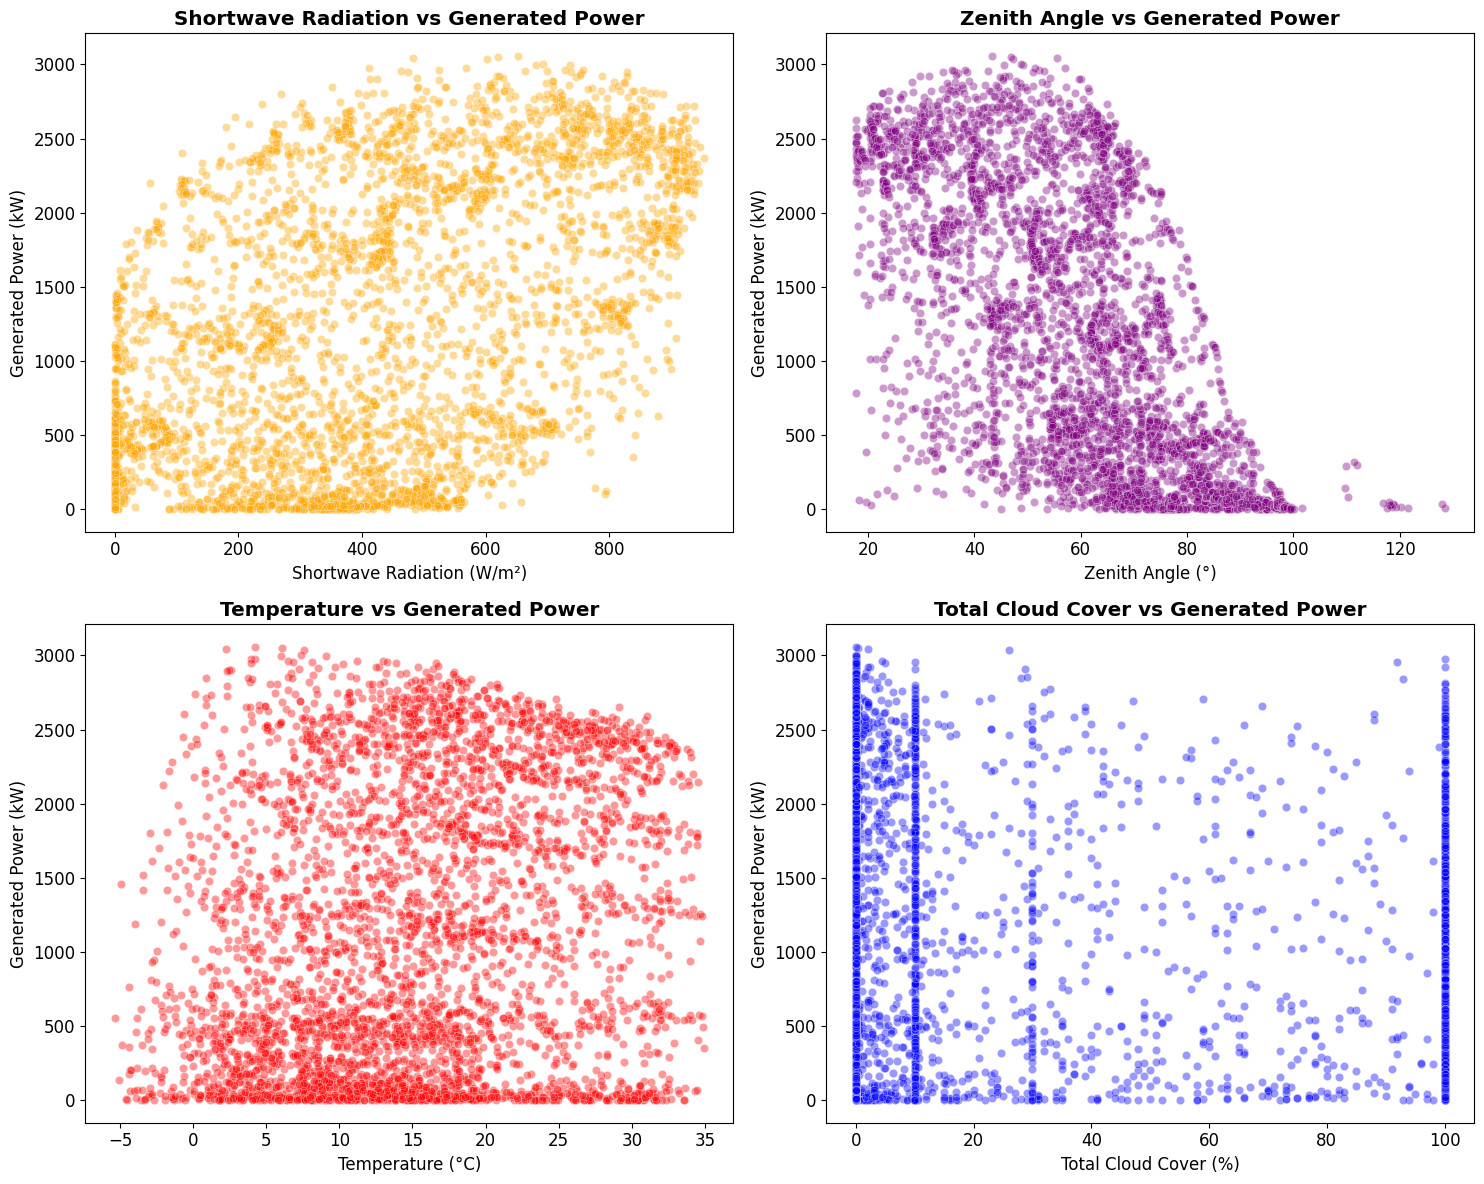

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(data=df, x='shortwave_radiation_backwards_sfc', y='generated_power_kw', alpha=0.4, color='orange', ax=axes[0, 0])
axes[0, 0].set_title('Shortwave Radiation vs Generated Power', fontweight='bold')
axes[0, 0].set_xlabel('Shortwave Radiation (W/m²)')
axes[0, 0].set_ylabel('Generated Power (kW)')

sns.scatterplot(data=df, x='zenith', y='generated_power_kw', alpha=0.4, color='purple', ax=axes[0, 1])
axes[0, 1].set_title('Zenith Angle vs Generated Power', fontweight='bold')
axes[0, 1].set_xlabel('Zenith Angle (°)')
axes[0, 1].set_ylabel('Generated Power (kW)')

sns.scatterplot(data=df, x='temperature_2_m_above_gnd', y='generated_power_kw', alpha=0.4, color='red', ax=axes[1, 0])
axes[1, 0].set_title('Temperature vs Generated Power', fontweight='bold')
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Generated Power (kW)')

sns.scatterplot(data=df, x='total_cloud_cover_sfc', y='generated_power_kw', alpha=0.4, color='blue', ax=axes[1, 1])
axes[1, 1].set_title('Total Cloud Cover vs Generated Power', fontweight='bold')
axes[1, 1].set_xlabel('Total Cloud Cover (%)')
axes[1, 1].set_ylabel('Generated Power (kW)')

plt.tight_layout()
plt.show()



## 2. Feature Engineering & Selection

### Column Removal & Derived Features Rationale
- **Dropped Features**:
  - `wind_speed_80_m_above_gnd`, `wind_speed_900_mb`: Highly collinear with `wind_speed_10_m_above_gnd`.
  - `wind_direction_80_m_above_gnd`, `wind_direction_900_mb`: Redundant with `wind_direction_10_m_above_gnd`.
  - `high_cloud_cover_high_cld_lay`, `medium_cloud_cover_mid_cld_lay`, `low_cloud_cover_low_cld_lay`: Summarized comprehensively by `total_cloud_cover_sfc`.
  - `snowfall_amount_sfc`, `total_precipitation_sfc`: Extremely sparse (>95% zeros), low predictive impact.
- **Derived Features**:
  - `clear_sky_index`: (100 - total_cloud_cover_sfc) / 100.0
  - `effective_irradiance`: shortwave_radiation_backwards_sfc * cos(zenith_rad)



In [8]:
df_fe = df.copy()

# Derived features
df_fe['clear_sky_index'] = (100.0 - df_fe['total_cloud_cover_sfc']) / 100.0
df_fe['zenith_rad'] = np.radians(df_fe['zenith'])
df_fe['effective_irradiance'] = df_fe['shortwave_radiation_backwards_sfc'] * np.cos(df_fe['zenith_rad'])

selected_features = [
    'temperature_2_m_above_gnd',
    'relative_humidity_2_m_above_gnd',
    'mean_sea_level_pressure_MSL',
    'total_cloud_cover_sfc',
    'shortwave_radiation_backwards_sfc',
    'wind_speed_10_m_above_gnd',
    'wind_direction_10_m_above_gnd',
    'angle_of_incidence',
    'zenith',
    'azimuth',
    'clear_sky_index',
    'effective_irradiance'
]

X = df_fe[selected_features]
y = df_fe['generated_power_kw']

print(f"Final Selected Features ({len(selected_features)}):")
for f in selected_features:
    print(f" - {f}")



Final Selected Features (12):
 - temperature_2_m_above_gnd
 - relative_humidity_2_m_above_gnd
 - mean_sea_level_pressure_MSL
 - total_cloud_cover_sfc
 - shortwave_radiation_backwards_sfc
 - wind_speed_10_m_above_gnd
 - wind_direction_10_m_above_gnd
 - angle_of_incidence
 - zenith
 - azimuth
 - clear_sky_index
 - effective_irradiance


## 3. Data Preprocessing

### Train-Test Split & Standard Scaling
- **Train/Test Split**: 80% training set (3,370 samples), 20% test set (843 samples) with `random_state=42`.
- **Standard Scaling**: Features scaled using `StandardScaler` (mean=0, std=1).
- **Why Scaling is Required**: Linear models and Gradient Descent optimize weights based on feature magnitude gradients. Without scaling, pressure (~1020 hPa) or radiation (~500 W/m²) would dominate gradients over cloud cover ratio (0-1), causing unstable optimization paths.



In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Samples: {X_train_scaled.shape[0]}")
print(f"Testing Samples:  {X_test_scaled.shape[0]}")



Training Samples: 3370
Testing Samples:  843


## 4. Regression Model Implementation & Comparison

We evaluate 4 Scikit-Learn regression models:
1. **Linear Regression**
2. **Stochastic Gradient Descent (SGD) Regression**
3. **Decision Tree Regression**
4. **Random Forest Regression**

Metrics evaluated:
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **R² Score**



In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "SGD Regression": SGDRegressor(max_iter=2000, tol=1e-4, random_state=42),
    "Decision Tree Regression": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest Regression": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
}

comparison_data = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    fitted_models[name] = (model, preds)
    comparison_data.append({
        "Model": name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(by="R2 Score", ascending=False)
print("=== MODEL COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))



=== MODEL COMPARISON TABLE ===
                   Model         MSE     RMSE  R2 Score
Random Forest Regression 173344.7704 416.3469    0.8102
       Linear Regression 255899.5451 505.8651    0.7199
          SGD Regression 256630.5130 506.5871    0.7191
Decision Tree Regression 259854.2746 509.7590    0.7155


### Visualization 4: Regression Line & Actual vs Predicted Performance
We plot Actual vs Predicted Solar Power for the best performing model (**Random Forest Regression**) along with an ideal prediction line (y = x).

**Explanations**:
- **What it shows**: Tight alignment along the ideal diagonal line across low, mid, and high generation outputs.
- **Model Decisions**: Confirms that non-linear ensemble tree structures capture physical solar radiation dynamics with minimal variance.



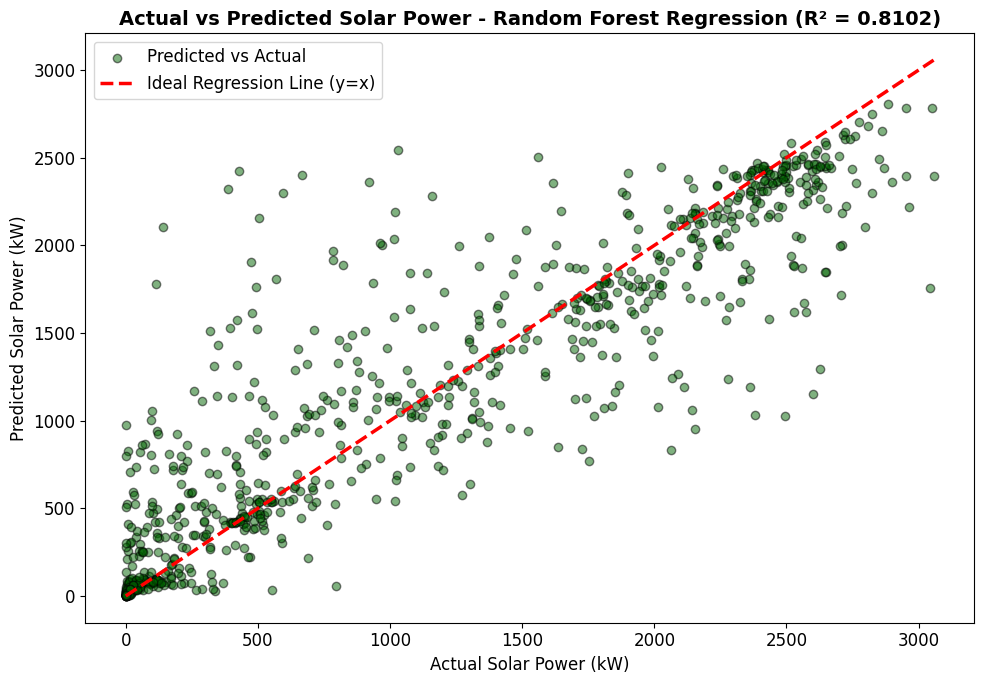

In [11]:
best_model_name = comparison_df.iloc[0]['Model']
best_preds = fitted_models[best_model_name][1]

plt.figure(figsize=(10, 7))
plt.scatter(y_test, best_preds, alpha=0.5, color='darkgreen', edgecolors='k', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Ideal Regression Line (y=x)')
plt.title(f'Actual vs Predicted Solar Power - {best_model_name} (R² = {comparison_df.iloc[0]["R2 Score"]})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Solar Power (kW)', fontsize=12)
plt.ylabel('Predicted Solar Power (kW)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()



## 5. Custom Gradient Descent Implementation

We build a custom Linear Regression model trained using Batch Gradient Descent from scratch.

### Mathematical Formulation
- **Hypothesis**: y_pred = X * W + b
- **Cost Function (MSE)**: J(W, b) = mean((y_pred - y)^2)
- **Gradients**:
  - dW = (2 / m) * X^T * (y_pred - y)
  - db = (2 / m) * sum(y_pred - y)



In [12]:
class CustomGradientDescentRegressor:
    def __init__(self, learning_rate=0.01, epochs=500):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None
        self.train_losses = []
        self.test_losses = []

    def fit(self, X_tr, y_tr, X_te, y_te):
        m, n = X_tr.shape
        self.w = np.zeros(n)
        self.b = 0.0
        
        y_tr_arr = y_tr.values if isinstance(y_tr, pd.Series) else y_tr
        y_te_arr = y_te.values if isinstance(y_te, pd.Series) else y_te

        for epoch in range(self.epochs):
            y_pred_tr = np.dot(X_tr, self.w) + self.b
            loss_tr = np.mean((y_pred_tr - y_tr_arr) ** 2)
            self.train_losses.append(loss_tr)

            y_pred_te = np.dot(X_te, self.w) + self.b
            loss_te = np.mean((y_pred_te - y_te_arr) ** 2)
            self.test_losses.append(loss_te)

            dw = (2 / m) * np.dot(X_tr.T, (y_pred_tr - y_tr_arr))
            db = (2 / m) * np.sum(y_pred_tr - y_tr_arr)

            self.w -= self.lr * dw
            self.b -= self.lr * db

gd_model = CustomGradientDescentRegressor(learning_rate=0.05, epochs=600)
gd_model.fit(X_train_scaled, y_train, X_test_scaled, y_test)

print(f"Final Train Loss (MSE): {gd_model.train_losses[-1]:.4f}")
print(f"Final Test Loss (MSE):  {gd_model.test_losses[-1]:.4f}")
print(f"Final Test RMSE:        {np.sqrt(gd_model.test_losses[-1]):.4f}")



Final Train Loss (MSE): 261194.0497
Final Test Loss (MSE):  256417.4798
Final Test RMSE:        506.3768


### Training Loss vs Epochs & Testing Loss vs Epochs
We plot the convergence curves for custom gradient descent.

**Explanations**:
- **Loss Trajectory**: Smooth exponential decay of training and testing loss, plateauing after ~300 epochs without overfitting.
- **Why Loss Exists**: Linear boundaries cannot fully capture complex multi-variable non-linear physical interactions between solar angle, cloud diffusion, and panel temperature.
- **Hyperparameter Optimization**: A learning rate alpha = 0.05 provides smooth convergence without gradient divergence.



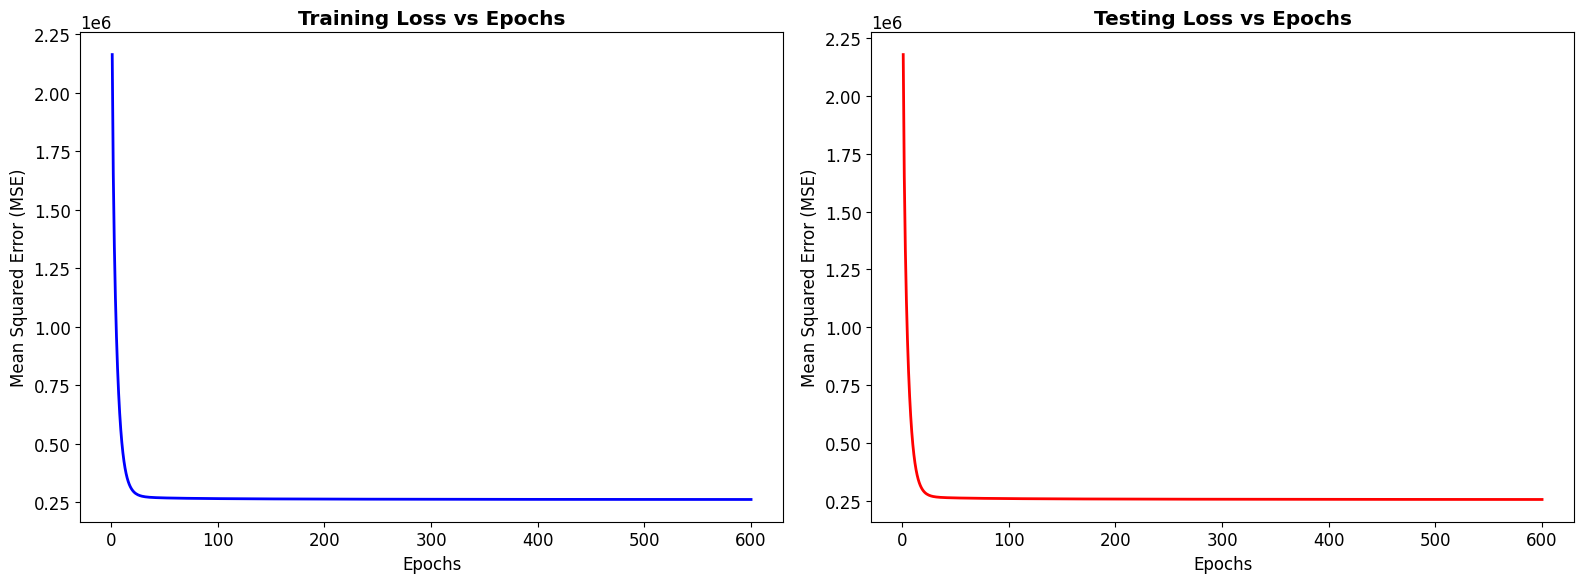

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, gd_model.epochs + 1), gd_model.train_losses, color='blue', lw=2)
axes[0].set_title('Training Loss vs Epochs', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Squared Error (MSE)')

axes[1].plot(range(1, gd_model.epochs + 1), gd_model.test_losses, color='red', lw=2)
axes[1].set_title('Testing Loss vs Epochs', fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Mean Squared Error (MSE)')

plt.tight_layout()
plt.show()



## 6. Model Saving & Inference Verification

We save the best performing model (`RandomForestRegressor`) and the `StandardScaler` object to `summative/API/model/`.
- `best_model.pkl`
- `scaler.pkl`



In [14]:
save_dir = os.path.abspath(os.path.join("..", "API", "model"))
os.makedirs(save_dir, exist_ok=True)

best_model_instance = fitted_models[best_model_name][0]

model_path = os.path.join(save_dir, "best_model.pkl")
scaler_path = os.path.join(save_dir, "scaler.pkl")

joblib.dump(best_model_instance, model_path)
joblib.dump(scaler, scaler_path)

print(f"Successfully saved best model to: {model_path}")
print(f"Successfully saved scaler to:     {scaler_path}")



Successfully saved best model to: c:\Users\HP\Documents\flutter_projects\ML\linear_regression_model\summative\API\model\best_model.pkl
Successfully saved scaler to:     c:\Users\HP\Documents\flutter_projects\ML\linear_regression_model\summative\API\model\scaler.pkl


### Single Sample Prediction Functionality Test
Demonstrates loading saved artifacts and making a single sample prediction.



In [15]:
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

sample_data = {
    'temperature_2_m_above_gnd': 18.5,
    'relative_humidity_2_m_above_gnd': 42.0,
    'mean_sea_level_pressure_MSL': 1018.5,
    'total_cloud_cover_sfc': 15.0,
    'shortwave_radiation_backwards_sfc': 520.0,
    'wind_speed_10_m_above_gnd': 12.4,
    'wind_direction_10_m_above_gnd': 180.0,
    'angle_of_incidence': 35.2,
    'zenith': 45.0,
    'azimuth': 165.0,
    'clear_sky_index': (100.0 - 15.0) / 100.0,
    'effective_irradiance': 520.0 * np.cos(np.radians(45.0))
}

sample_df = pd.DataFrame([sample_data])
sample_scaled = loaded_scaler.transform(sample_df)

predicted_power = loaded_model.predict(sample_scaled)[0]

print("=== SAMPLE INPUT ===")
for k, v in sample_data.items():
    print(f" {k}: {v}")

print("\n=== PREDICTION RESULT ===")
print(f"Predicted Solar Power Generation: {predicted_power:.2f} kW")



=== SAMPLE INPUT ===
 temperature_2_m_above_gnd: 18.5
 relative_humidity_2_m_above_gnd: 42.0
 mean_sea_level_pressure_MSL: 1018.5
 total_cloud_cover_sfc: 15.0
 shortwave_radiation_backwards_sfc: 520.0
 wind_speed_10_m_above_gnd: 12.4
 wind_direction_10_m_above_gnd: 180.0
 angle_of_incidence: 35.2
 zenith: 45.0
 azimuth: 165.0
 clear_sky_index: 0.85
 effective_irradiance: 367.6955262170047

=== PREDICTION RESULT ===
Predicted Solar Power Generation: 1917.90 kW
